# PyTorch digit classification with Optuna — CPU

This notebook extends the previous PyTorch digits project by adding **Optuna** for hyperparameter tuning.

We keep the workflow CPU-only and tune a small set of understandable hyperparameters:

- learning rate
- batch size
- first hidden-layer size
- second hidden-layer size

The test set remains untouched during tuning. Optuna selects hyperparameters using a separate validation set.


In [3]:
# Run this once if Optuna is not installed:
# %pip install optuna


In [4]:
import time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import optuna
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances,
    plot_parallel_coordinate,
    plot_contour
)


from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

print("PyTorch version:", torch.__version__)
print("Optuna version:", optuna.__version__)


PyTorch version: 2.14.0+cpu
Optuna version: 5.0.0


## Load and prepare the data

We first create an untouched test set. The remaining data is then split into training and validation sets.

Optuna uses the validation accuracy to compare trials, while the final test set is used only after the best hyperparameters have been selected.


In [5]:
digits = load_digits()

X = digits.data
y = digits.target

print("Images shape:", digits.images.shape)
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Classes:", digits.target_names)


Images shape: (1797, 8, 8)
Feature matrix shape: (1797, 64)
Target shape: (1797,)
Classes: [0 1 2 3 4 5 6 7 8 9]


In [6]:
# 80% development data, 20% untouched test data
X_dev, X_test, y_dev, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Split the development data into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X_dev,
    y_dev,
    test_size=0.2,
    random_state=42,
    stratify=y_dev
)

# Scale pixel values from 0-16 to approximately 0-1
X_train = X_train / 16.0
X_val = X_val / 16.0
X_test = X_test / 16.0

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)


Training set: (1149, 64)
Validation set: (288, 64)
Test set: (360, 64)


In [7]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

device = torch.device("cpu")

print("Using device:", device)


Using device: cpu


## Define a configurable neural network

Unlike the previous fixed model, this network accepts the hidden-layer sizes as inputs so that Optuna can try different architectures.


In [8]:
class DigitClassifier(nn.Module):
    def __init__(self, hidden1=128, hidden2=64):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(64, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, 10)
        )

    def forward(self, x):
        return self.network(x)


## Define the Optuna objective

Each Optuna trial:

1. chooses a set of hyperparameters,
2. creates a new model,
3. trains it on the training set,
4. evaluates it on the validation set,
5. returns validation accuracy.

Optuna then searches for the configuration that maximizes validation accuracy.


In [9]:
def objective(trial):

    # Hyperparameters to tune
    hidden1 = trial.suggest_categorical(
        "hidden1",
        [64, 128, 256]
    )

    hidden2 = trial.suggest_categorical(
        "hidden2",
        [32, 64, 128]
    )

    learning_rate = trial.suggest_float(
        "learning_rate",
        1e-4,
        1e-2,
        log=True
    )

    batch_size = trial.suggest_categorical(
        "batch_size",
        [16, 32, 64]
    )

    # Create DataLoader for this trial
    train_dataset = TensorDataset(
        X_train_tensor,
        y_train_tensor
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    # New model for every trial
    model = DigitClassifier(
        hidden1=hidden1,
        hidden2=hidden2
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    epochs = 25

    # Train
    for epoch in range(epochs):
        model.train()

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            loss.backward()
            optimizer.step()

    # Validate
    model.eval()

    with torch.no_grad():
        val_outputs = model(X_val_tensor.to(device))
        val_predictions = torch.argmax(val_outputs, dim=1)

    val_accuracy = accuracy_score(
        y_val,
        val_predictions.cpu().numpy()
    )

    return val_accuracy


## Run the Optuna study

We start with 20 trials. This is enough to demonstrate the tuning workflow without making the experiment unnecessarily long.


In [10]:
study = optuna.create_study(
    direction="maximize"
)

start_time = time.time()

study.optimize(
    objective,
    n_trials=20
)

optuna_time = time.time() - start_time

print(f"Optuna tuning time: {optuna_time:.2f} seconds")


[I 2026-09-19 22:45:51,014] A new study created in memory with name: no-name-a7fb2e91-9012-4626-a865-0bb5621d63b2
[I 2026-09-19 22:45:55,717] Trial 0 finished with value: 0.9513888888888888 and parameters: {'hidden1': 128, 'hidden2': 32, 'learning_rate': 0.00016219908185487113, 'batch_size': 16}. Best is trial 0 with value: 0.9513888888888888.
[I 2026-09-19 22:45:57,260] Trial 1 finished with value: 0.9756944444444444 and parameters: {'hidden1': 64, 'hidden2': 64, 'learning_rate': 0.004995463780109513, 'batch_size': 32}. Best is trial 1 with value: 0.9756944444444444.
[I 2026-09-19 22:45:58,325] Trial 2 finished with value: 0.9826388888888888 and parameters: {'hidden1': 256, 'hidden2': 128, 'learning_rate': 0.00647017609280107, 'batch_size': 64}. Best is trial 2 with value: 0.9826388888888888.
[I 2026-09-19 22:45:59,261] Trial 3 finished with value: 0.9618055555555556 and parameters: {'hidden1': 128, 'hidden2': 128, 'learning_rate': 0.0004107075608735171, 'batch_size': 64}. Best is tri

Optuna tuning time: 32.01 seconds


In [11]:
# 1. Validation accuracy across trials
plot_optimization_history(study).show()

# 2. Which hyperparameters influenced accuracy the most?
plot_param_importances(study).show()

# 3. View all hyperparameters together
plot_parallel_coordinate(
    study,
    params=[
        "learning_rate",
        "batch_size",
        "hidden1",
        "hidden2"
    ]
).show()

# 4. 2D interaction between two important hyperparameters
plot_contour(
    study,
    params=[
        "learning_rate",
        "hidden1"
    ]
).show()

In [12]:
print("Best validation accuracy:")
print(study.best_value)

print("\nBest hyperparameters:")
for key, value in study.best_params.items():
    print(f"{key}: {value}")


Best validation accuracy:
0.9895833333333334

Best hyperparameters:
hidden1: 256
hidden2: 64
learning_rate: 0.0027976364494529766
batch_size: 32


## Inspect the tuning results

The table below shows how the trials performed and which hyperparameter combinations were tested.


In [13]:
trials_df = study.trials_dataframe()

trials_df[
    [
        "number",
        "value",
        "params_hidden1",
        "params_hidden2",
        "params_learning_rate",
        "params_batch_size"
    ]
].sort_values(
    "value",
    ascending=False
).head(10)


,number,value,params_hidden1,params_hidden2,params_learning_rate,params_batch_size
15,15,0.989583,256,64,0.002798,32
8,8,0.986111,256,64,0.001500,32
11,11,0.986111,256,128,0.004892,64
16,16,0.986111,256,64,0.002623,32
5,5,0.982639,128,64,0.003432,16
13,13,0.982639,256,32,0.002984,32
6,6,0.982639,64,128,0.009153,16
2,2,0.982639,256,128,0.006470,64
17,17,0.979167,256,32,0.007381,32
1,1,0.975694,64,64,0.004995,32


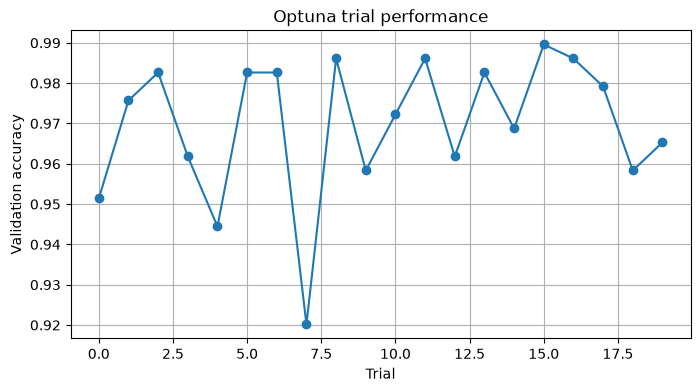

In [14]:
plt.figure(figsize=(8, 4))

plt.plot(
    trials_df["number"],
    trials_df["value"],
    marker="o"
)

plt.xlabel("Trial")
plt.ylabel("Validation accuracy")
plt.title("Optuna trial performance")
plt.grid(True)

plt.show()


## Retrain the final model

After tuning, we combine the original training and validation data and train one final model using the best hyperparameters.

Only after this step do we evaluate on the untouched test set.


In [15]:
best_params = study.best_params

X_final_train = np.vstack([X_train, X_val])
y_final_train = np.concatenate([y_train, y_val])

X_final_train_tensor = torch.tensor(
    X_final_train,
    dtype=torch.float32
)

y_final_train_tensor = torch.tensor(
    y_final_train,
    dtype=torch.long
)

final_dataset = TensorDataset(
    X_final_train_tensor,
    y_final_train_tensor
)

final_loader = DataLoader(
    final_dataset,
    batch_size=best_params["batch_size"],
    shuffle=True
)

final_model = DigitClassifier(
    hidden1=best_params["hidden1"],
    hidden2=best_params["hidden2"]
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    final_model.parameters(),
    lr=best_params["learning_rate"]
)


In [16]:
epochs = 20
loss_history = []

start_time = time.time()

for epoch in range(epochs):
    final_model.train()
    running_loss = 0.0

    for X_batch, y_batch in final_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = final_model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(final_loader)
    loss_history.append(epoch_loss)

    print(
        f"Epoch {epoch + 1:02d}/{epochs} "
        f"- Loss: {epoch_loss:.4f}"
    )

final_training_time = time.time() - start_time

print(f"\nFinal training time: {final_training_time:.2f} seconds")


Epoch 01/20 - Loss: 1.3071
Epoch 02/20 - Loss: 0.2832
Epoch 03/20 - Loss: 0.1764
Epoch 04/20 - Loss: 0.1458
Epoch 05/20 - Loss: 0.1046
Epoch 06/20 - Loss: 0.0711
Epoch 07/20 - Loss: 0.0556
Epoch 08/20 - Loss: 0.0501
Epoch 09/20 - Loss: 0.0406
Epoch 10/20 - Loss: 0.0334
Epoch 11/20 - Loss: 0.0305
Epoch 12/20 - Loss: 0.0346
Epoch 13/20 - Loss: 0.0218
Epoch 14/20 - Loss: 0.0311
Epoch 15/20 - Loss: 0.0275
Epoch 16/20 - Loss: 0.0150
Epoch 17/20 - Loss: 0.0091
Epoch 18/20 - Loss: 0.0059
Epoch 19/20 - Loss: 0.0054
Epoch 20/20 - Loss: 0.0038

Final training time: 1.59 seconds


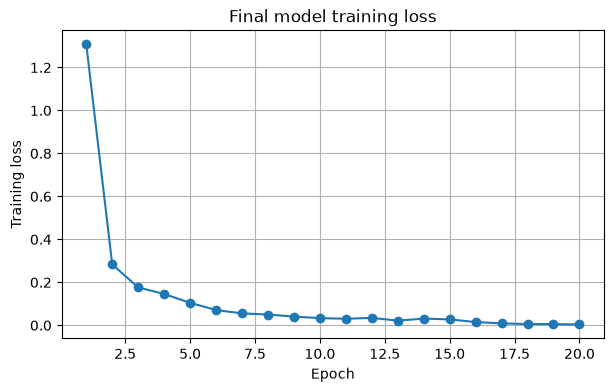

In [17]:
plt.figure(figsize=(7, 4))

plt.plot(
    range(1, epochs + 1),
    loss_history,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Final model training loss")
plt.grid(True)

plt.show()


## Final evaluation on the untouched test set

This test result is the most important score because the test set was not used to choose the hyperparameters.


In [18]:
final_model.eval()

with torch.no_grad():
    test_outputs = final_model(
        X_test_tensor.to(device)
    )

    test_predictions = torch.argmax(
        test_outputs,
        dim=1
    )

test_predictions_np = test_predictions.cpu().numpy()

test_accuracy = accuracy_score(
    y_test,
    test_predictions_np
)

print(f"Final test accuracy: {test_accuracy:.4f}")
print(f"Final test accuracy: {test_accuracy * 100:.2f}%")


Final test accuracy: 0.9694
Final test accuracy: 96.94%


In [19]:
print(
    classification_report(
        y_test,
        test_predictions_np
    )
)


              precision    recall  f1-score   support

           0       1.00      0.97      0.99        36
           1       0.91      0.86      0.89        36
           2       1.00      1.00      1.00        35
           3       0.97      1.00      0.99        37
           4       0.97      1.00      0.99        36
           5       1.00      1.00      1.00        37
           6       1.00      0.97      0.99        36
           7       0.97      1.00      0.99        36
           8       0.89      0.89      0.89        35
           9       0.97      1.00      0.99        36

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



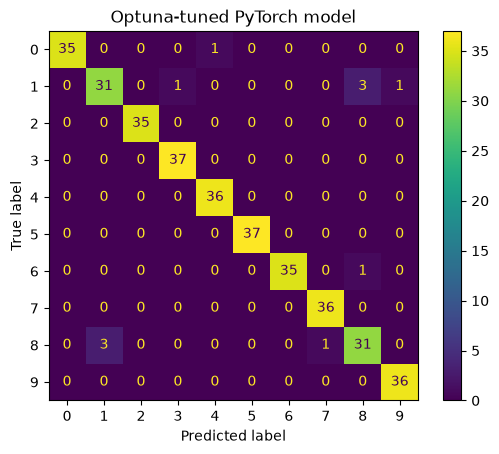

In [20]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions_np
)

plt.title("Optuna-tuned PyTorch model")
plt.show()


## Inspect misclassified samples

As before, we inspect some incorrect predictions to understand where the tuned model still makes mistakes.


Number of misclassified samples: 11


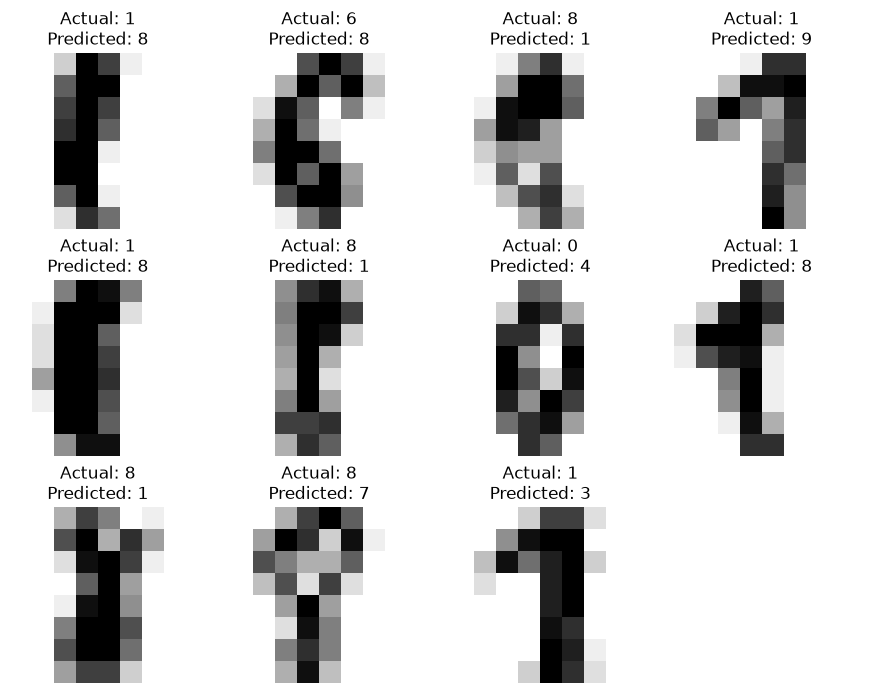

In [21]:
wrong_indices = np.where(
    test_predictions_np != y_test
)[0]

print("Number of misclassified samples:", len(wrong_indices))

num_to_show = min(12, len(wrong_indices))

fig, axes = plt.subplots(3, 4, figsize=(9, 7))

for ax, idx in zip(
    axes.ravel(),
    wrong_indices[:num_to_show]
):
    ax.imshow(
        X_test[idx].reshape(8, 8),
        cmap="gray_r"
    )

    ax.set_title(
        f"Actual: {y_test[idx]}\n"
        f"Predicted: {test_predictions_np[idx]}"
    )

    ax.axis("off")

for ax in axes.ravel()[num_to_show:]:
    ax.axis("off")

plt.tight_layout()
plt.show()


## Summary

This version adds a proper hyperparameter-tuning workflow:

`train → validation tuning with Optuna → best hyperparameters → retrain → final test evaluation`

The important distinction is that **model parameters** are learned by backpropagation, while **hyperparameters** such as learning rate, batch size, and hidden-layer size are selected by the tuning process.
